## Supply Chain Optimization Analytics
### Executive-Level Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)

# chart style
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv("/Users/umangverma/Supply-Chain-Optimization-Analytics/data/cleaned_supply_chain_data.csv")

In [4]:
df.head()

,product_type,sku,price,availability,products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,shipping_times,shipping_carriers,shipping_costs,supplier_name,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs,estimated_profit,profit_margin_pct,inventory_turnover,supply_chain_efficiency,supplier_risk,inventory_status,cost_per_unit_sold
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075,8425.008266,97.264043,13.827586,36.550279,Low Risk,Sufficient Stock,0.295497
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579,6914.501143,92.676501,13.886792,13.654676,High Risk,Sufficient Stock,0.742390
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282,9397.086845,98.113724,8.000000,53.014515,High Risk,Low Stock,22.582848
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159,7474.705957,96.238746,3.608696,26.586876,High Risk,Sufficient Stock,3.519644
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632,1667.108811,62.054927,174.200000,2.635388,High Risk,Low Stock,1.170375


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_type             100 non-null    object 
 1   sku                      100 non-null    object 
 2   price                    100 non-null    float64
 3   availability             100 non-null    int64  
 4   products_sold            100 non-null    int64  
 5   revenue_generated        100 non-null    float64
 6   customer_demographics    100 non-null    object 
 7   stock_levels             100 non-null    int64  
 8   lead_times               100 non-null    int64  
 9   order_quantities         100 non-null    int64  
 10  shipping_times           100 non-null    int64  
 11  shipping_carriers        100 non-null    object 
 12  shipping_costs           100 non-null    float64
 13  supplier_name            100 non-null    object 
 14  location                 10

In [6]:
df.describe()

,price,availability,products_sold,revenue_generated,stock_levels,lead_times,order_quantities,shipping_times,shipping_costs,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,defect_rates,costs,estimated_profit,profit_margin_pct,inventory_turnover,supply_chain_efficiency,cost_per_unit_sold
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782,5193.987563,86.066707,inf,13.270197,3.178457
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696,2744.510870,11.083219,NaN,11.873935,5.588238
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248,739.849765,46.051103,0.258065,1.853606,0.165458
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455,2312.805146,82.222943,4.574373,5.625237,0.692132
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444,5356.929512,89.540644,8.698822,9.560896,1.331848
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231,7639.571804,93.196058,20.531907,14.697658,3.382563
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450,9397.086845,98.219015,inf,56.148710,36.834614


KPI Summary Section

In [7]:
total_revenue = df['revenue_generated'].sum()
total_products_sold = df['products_sold'].sum()
avg_shipping_cost = df['shipping_costs'].mean()
avg_defect_rate = df['defect_rates'].mean()

print("Total Revenue:", round(total_revenue,2))
print("Total Products Sold:", total_products_sold)
print("Average Shipping Cost:", round(avg_shipping_cost,2))
print("Average Defect Rate:", round(avg_defect_rate,2))

Total Revenue: 577604.82
Total Products Sold: 46099
Average Shipping Cost: 5.55
Average Defect Rate: 2.28


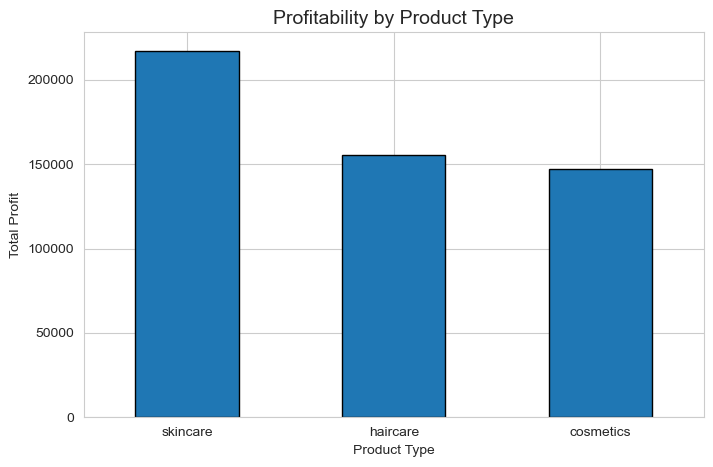

In [13]:
plt.figure(figsize=(8,5))

profitability.plot(kind='bar',edgecolor='black')

plt.title('Profitability by Product Type', fontsize=14)
plt.xlabel('Product Type')
plt.ylabel('Total Profit')

plt.xticks(rotation=0)

plt.show()

Insight:
Skincare products contribute the highest overall profitability,
indicating stronger demand performance and operational efficiency.

### Supplier Defect Rate Chart

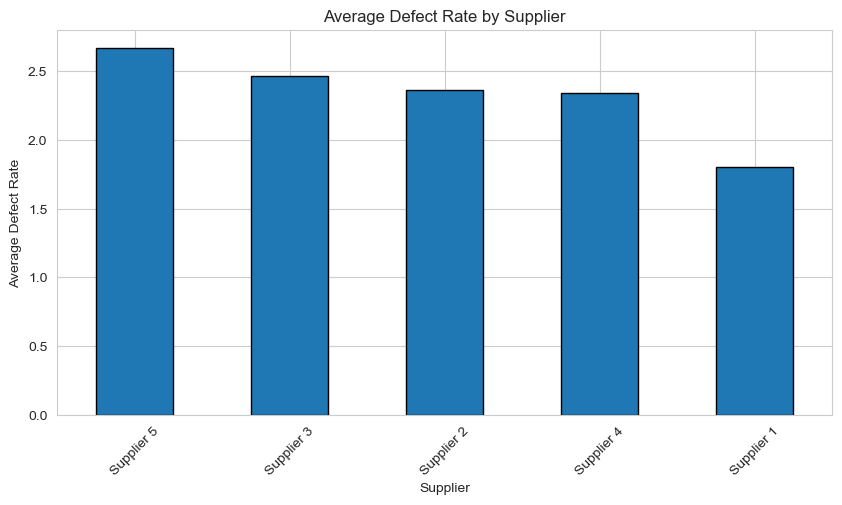

In [12]:
supplier_defects = df.groupby('supplier_name')['defect_rates'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

supplier_defects.plot(kind='bar', edgecolor='black')

plt.title('Average Defect Rate by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Average Defect Rate')

plt.xticks(rotation=45)

plt.show()

Insight:

Supplier5 demonstrates the highest average defect rate across the supplier network, indicating elevated operational and quality-related risk exposure. Higher defect frequency may contribute to increased rework costs, production inefficiencies, inventory waste, and customer dissatisfaction. In contrast, Supplier1 maintains comparatively lower defect rates, suggesting stronger quality control and operational consistency.

### Shipping Cost by Transportation Mode

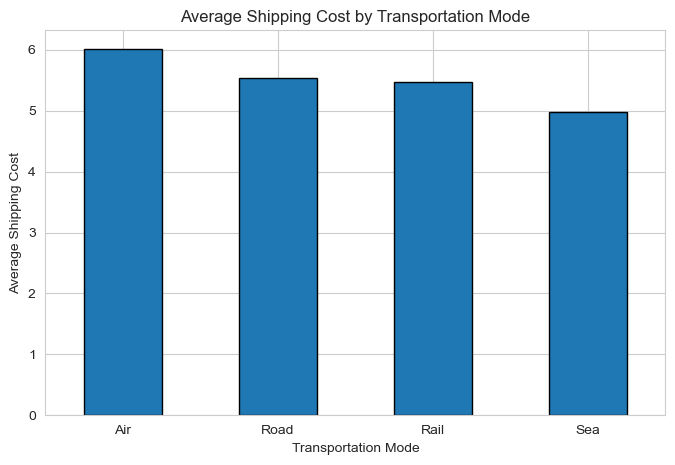

In [16]:
transport_cost = df.groupby('transportation_modes')['shipping_costs'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

transport_cost.plot(kind='bar',edgecolor='black')

plt.title('Average Shipping Cost by Transportation Mode')
plt.xlabel('Transportation Mode')
plt.ylabel('Average Shipping Cost')

plt.xticks(rotation=0)

plt.show()

Business Insight:

Air transportation incurs the highest average shipping costs across all logistics channels, indicating elevated transportation expenditure for premium delivery operations. In contrast, sea transportation demonstrates comparatively lower logistics costs, suggesting stronger cost efficiency for bulk transportation activities. These findings highlight opportunities to optimize transportation strategy by balancing delivery responsiveness against operational cost efficiency.

### Inventory Status Distribution Chart

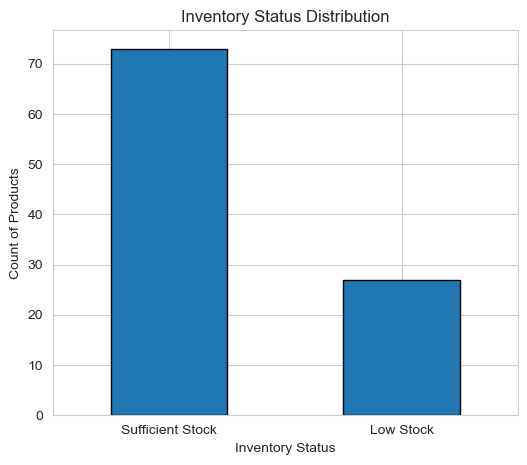

In [17]:
inventory_status = df['inventory_status'].value_counts()

plt.figure(figsize=(6,5))

inventory_status.plot(kind='bar',edgecolor='black')

plt.title('Inventory Status Distribution')
plt.xlabel('Inventory Status')
plt.ylabel('Count of Products')

plt.xticks(rotation=0)

plt.show()

Insight:

The majority of products maintain sufficient stock levels, indicating relatively stable inventory availability across the supply chain network. However, a meaningful portion of products continue operating under low-stock conditions, potentially exposing the organization to stockout risks, delayed fulfillment, and missed revenue opportunities during periods of increased customer demand.

### Route Performance Analysis

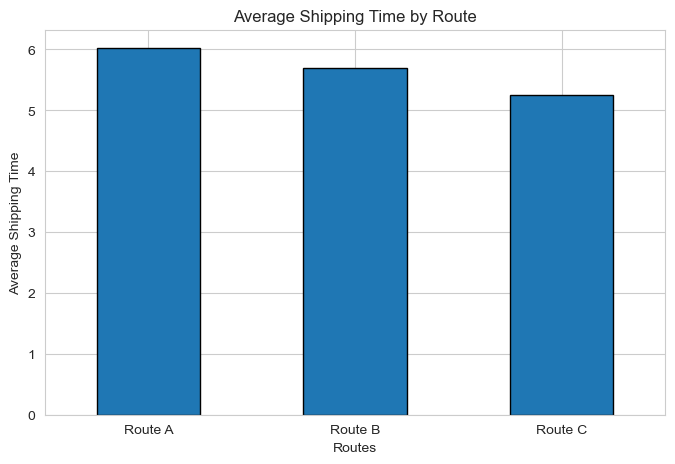

In [19]:
route_time = df.groupby('routes')['shipping_times'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

route_time.plot(
    kind='bar',
    edgecolor='black'
)

plt.title('Average Shipping Time by Route')
plt.xlabel('Routes')
plt.ylabel('Average Shipping Time')

plt.xticks(rotation=0)

plt.show()

Insight:

Route A demonstrates the highest average shipping time within the logistics network, indicating potential transportation bottlenecks and slower fulfillment responsiveness. Extended shipping durations may negatively impact operational agility, delivery performance, and customer satisfaction. In contrast, Route C exhibits relatively lower shipping times, suggesting stronger transportation efficiency and improved route optimization.

### Correlation Heatmap

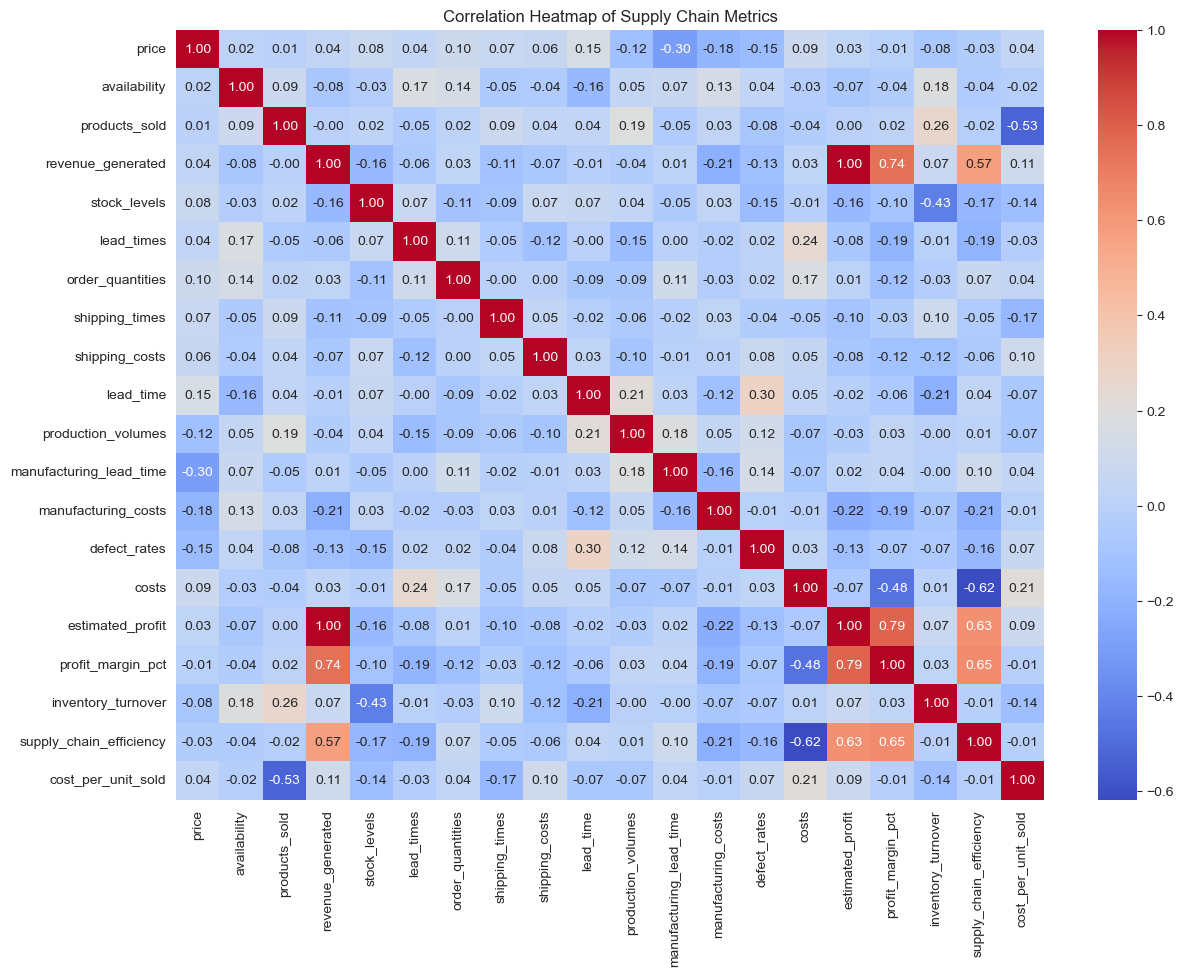

In [20]:
numeric_columns = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Supply Chain Metrics')

plt.show()

Correlation Insight:

The correlation analysis reveals strong positive relationships between estimated profit, profit margin percentage, and supply chain efficiency, indicating that operationally efficient supply chain processes contribute directly to profitability growth. Additionally, higher operational costs demonstrate a negative relationship with supply chain efficiency, suggesting that cost escalation may reduce overall operational performance. The analysis also highlights an inverse relationship between stock levels and inventory turnover, indicating potential inventory holding inefficiencies associated with excess stock accumulation.

# Summary

The analysis identified multiple operational opportunities across the supply chain ecosystem. Skincare products emerged as the strongest profitability driver due to high inventory turnover and operational efficiency. Supplier-level analysis revealed quality-related risks associated with Supplier5, while transportation analysis highlighted elevated logistics costs within air transportation operations. Inventory analysis demonstrated generally stable stock availability but identified potential low-stock exposure for selected products. Correlation analysis further confirmed that operational efficiency and profitability are strongly interconnected, emphasizing the importance of cost optimization and efficient supply chain execution for long-term business performance.

In [3]:
plt.savefig('../screenshots/chart_name.png',
            bbox_inches='tight',
            dpi=300)

<Figure size 640x480 with 0 Axes>